In [1]:
import matplotlib.image as image
import matplotlib.pyplot as plt
import numpy as np
import time
from numba import jit, cuda

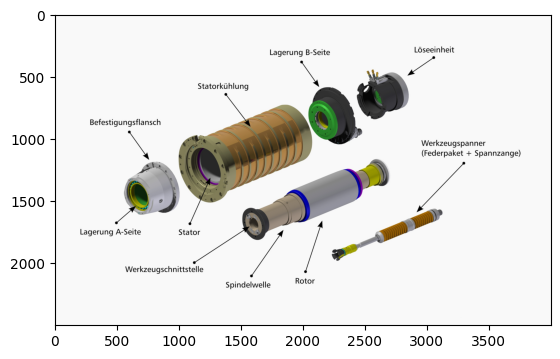

In [2]:
with open('./b.jpg', 'rb') as f:
    img = image.imread(f)
plt.imshow(img)
plt.show()

In [3]:
def gaussian(kernel_size=7, sigma=1.0):
    k = kernel_size // 2
    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)

    for y in range(-k, k + 1):
        for x in range(-k, k + 1):

            coefficient = 1.0 / (2.0 * np.pi * sigma**2)
            distance_squared = x**2 + y**2
            exponent = -distance_squared / (2.0 * sigma**2)
            gaussian_value = coefficient * np.exp(exponent)
            kernel[y + k, x + k] = gaussian_value

            # Normalize so all weights sum to 1
            kernel /= np.sum(kernel)
    return kernel

kernel = gaussian()

@cuda.jit
def gaussian_blur_kernel(input_img, output_img, kernel):
    x, y = cuda.grid(2)
    height = input_img.shape[0]
    width = input_img.shape[1]
    kernel_size = kernel.shape[0]
    k = kernel_size // 2

    if x < width and y < height:
        r_sum = 0.0
        g_sum = 0.0
        b_sum = 0.0

        for ky in range(-k, k + 1):
            for kx in range(-k, k + 1):
                # Handle edge cases by clamping pixel coordinates
                nx = min(max(x + kx, 0), width - 1)
                ny = min(max(y + ky, 0), height - 1)

                weight = kernel[ky + k, kx + k]

                r_sum += input_img[ny, nx, 0] * weight
                g_sum += input_img[ny, nx, 1] * weight
                b_sum += input_img[ny, nx, 2] * weight
                
        output_img[y, x, 0] = np.uint8(r_sum)
        output_img[y, x, 1] = np.uint8(g_sum)
        output_img[y, x, 2] = np.uint8(b_sum)

input_img = img.astype(np.uint8)
height = input_img.shape[0]
width = input_img.shape[1]
d_img = cuda.to_device(input_img)
d_blurred_img = cuda.device_array(input_img.shape, dtype=np.uint8)
d_kernel = cuda.to_device(kernel)

blockSize = (32, 32)
gridSize = (
    (width + blockSize[0] - 1) // blockSize[0],
    (height + blockSize[1] - 1) // blockSize[1]
)
start = time.time()
gaussian_blur_kernel[gridSize, blockSize](d_img, d_blurred_img, d_kernel)
cuda.synchronize()
end = time.time()
output_img = d_blurred_img.copy_to_host()
print(f"Execution time: {end - start:.6f} seconds")

Execution time: 0.772504 seconds


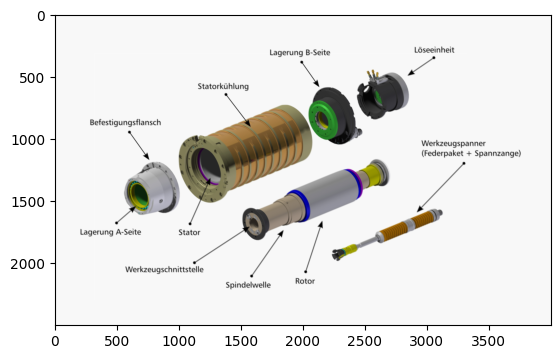

In [4]:
plt.imshow(output_img)
plt.show()

In [12]:
kernel_size = 7
radius = kernel_size // 2
blockSize = (32, 32)
mem_size = (blockSize[0] + 2 * radius, blockSize[1] + 2 * radius, radius)
@cuda.jit
def gaussian_blur_shared(input_img, output_img, kernel):
    x, y = cuda.grid(2)
    shared = cuda.shared.array(shape=mem_size, dtype=cuda.uint8)

    tx, ty = cuda.threadIdx.x, cuda.threadIdx.y
    x = cuda.blockIdx.x * blockSize[0] + tx
    y = cuda.blockIdx.y * blockSize[1] + ty

    width = input_img.shape[1]
    height = input_img.shape[0]

    shared_width = blockSize[0] + 2 * radius
    shared_height = blockSize[1] + 2 * radius

    tid = ty * blockSize[0] + tx
    threads_per_block = blockSize[0] * blockSize[1]
    total_shared_pixels = shared_width * shared_height

    i = tid

    while i < total_shared_pixels:

        sy = i // shared_width
        sx = i % shared_width

        # Corresponding global coordinates
        gx = cuda.blockIdx.x * blockSize[0] + sx - radius
        gy = cuda.blockIdx.y * blockSize[1] + sy - radius

        # Clamp image boundaries
        gx = min(max(gx, 0), width - 1)
        gy = min(max(gy, 0), height - 1)

        shared[sy, sx, 0] = input_img[gy, gx, 0]
        shared[sy, sx, 1] = input_img[gy, gx, 1]
        shared[sy, sx, 2] = input_img[gy, gx, 2]

        i += threads_per_block

    # Wait until all threads finish loading
    cuda.syncthreads()

    # Gaussian convolution
    if x < width and y < height:

        r_sum = 0.0
        g_sum = 0.0
        b_sum = 0.0

        # Position of current pixel in shared memory
        center_x = tx + radius
        center_y = ty + radius

        for ky in range(-radius, radius + 1):
            for kx in range(-radius, radius + 1):

                weight = kernel[
                    ky + radius,
                    kx + radius
                ]

                sx = center_x + kx
                sy = center_y + ky

                r_sum += shared[sy, sx, 0] * weight
                g_sum += shared[sy, sx, 1] * weight
                b_sum += shared[sy, sx, 2] * weight

        output_img[y, x, 0] = np.uint8(r_sum)
        output_img[y, x, 1] = np.uint8(g_sum)
        output_img[y, x, 2] = np.uint8(b_sum)
start = time.time()
gaussian_blur_shared[gridSize, blockSize](d_img, d_blurred_img, d_kernel)
cuda.synchronize()
end = time.time()
print(f"Execution time with shared memory: {(end - start)*1000:.6f} ms")
output_img = d_blurred_img.copy_to_host()


Execution time with shared memory: 671.770811 ms


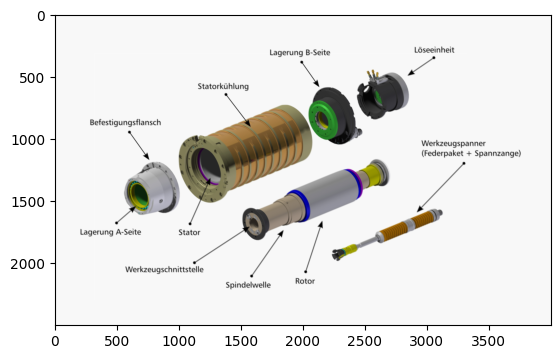

In [6]:
plt.imshow(output_img)

# BlockSizes vs Speed 

In [7]:
kernel_size = 7
radius = kernel_size // 2


def create_gaussian_blur_kernel(block_size):

    block_x, block_y = block_size

    shared_width = block_x + 2 * radius
    shared_height = block_y + 2 * radius

    # [height, width, RGB]
    mem_size = (shared_height, shared_width, 3)

    @cuda.jit
    def gaussian_blur_shared(input_img, output_img, kernel):

        tx = cuda.threadIdx.x
        ty = cuda.threadIdx.y

        x = cuda.blockIdx.x * block_x + tx
        y = cuda.blockIdx.y * block_y + ty

        width = input_img.shape[1]
        height = input_img.shape[0]

        shared = cuda.shared.array(shape=mem_size, dtype=cuda.uint8)

        # Linear thread ID
        tid = ty * block_x + tx

        threads_per_block = block_x * block_y
        total_shared_pixels = shared_width * shared_height

        i = tid

        # Load image + halo into shared memory
        while i < total_shared_pixels:

            sy = i // shared_width
            sx = i % shared_width

            gx = cuda.blockIdx.x * block_x + sx - radius
            gy = cuda.blockIdx.y * block_y + sy - radius

            # Clamp
            gx = min(max(gx, 0), width - 1)
            gy = min(max(gy, 0), height - 1)

            shared[sy, sx, 0] = input_img[gy, gx, 0]
            shared[sy, sx, 1] = input_img[gy, gx, 1]
            shared[sy, sx, 2] = input_img[gy, gx, 2]

            i += threads_per_block

        cuda.syncthreads()

        # Gaussian convolution
        if x < width and y < height:

            r_sum = 0.0
            g_sum = 0.0
            b_sum = 0.0

            center_x = tx + radius
            center_y = ty + radius

            for ky in range(-radius, radius + 1):

                for kx in range(-radius, radius + 1):

                    weight = kernel[ky + radius, kx + radius]

                    sx = center_x + kx
                    sy = center_y + ky

                    r_sum += shared[sy, sx, 0] * weight
                    g_sum += shared[sy, sx, 1] * weight
                    b_sum += shared[sy, sx, 2] * weight

            output_img[y, x, 0] = np.uint8(r_sum)
            output_img[y, x, 1] = np.uint8(g_sum)
            output_img[y, x, 2] = np.uint8(b_sum)

    return gaussian_blur_shared

In [9]:
block_sizes = [
    (2, 2),
    (4, 4),
    (8, 8),
    (16, 16),
    (32, 32)
]

times = []

height = d_img.shape[0]
width = d_img.shape[1]

for blockSize in block_sizes:

    block_x, block_y = blockSize

    gridSize = (
        (width + block_x - 1) // block_x,
        (height + block_y - 1) // block_y
    )

    # Create kernel for this block size
    kernel_func = create_gaussian_blur_kernel(blockSize)

    # Warm-up
    kernel_func[gridSize, blockSize](
        d_img,
        d_blurred_img,
        d_kernel
    )

    cuda.synchronize()

    # Benchmark
    start = time.perf_counter()

    kernel_func[gridSize, blockSize](
        d_img,
        d_blurred_img,
        d_kernel
    )

    cuda.synchronize()

    end = time.perf_counter()

    elapsed = (end - start) * 1000

    times.append(elapsed)

    print(
        f"Block: {blockSize}, "
        f"Grid: {gridSize}, "
        f"Threads/block: {block_x * block_y}, "
        f"Time: {elapsed:.3f} ms"
    )

Block: (2, 2), Grid: (2000, 1250), Threads/block: 4, Time: 216.213 ms
Block: (4, 4), Grid: (1000, 625), Threads/block: 16, Time: 53.708 ms
Block: (8, 8), Grid: (500, 313), Threads/block: 64, Time: 26.972 ms
Block: (16, 16), Grid: (250, 157), Threads/block: 256, Time: 26.855 ms
Block: (32, 32), Grid: (125, 79), Threads/block: 1024, Time: 27.524 ms


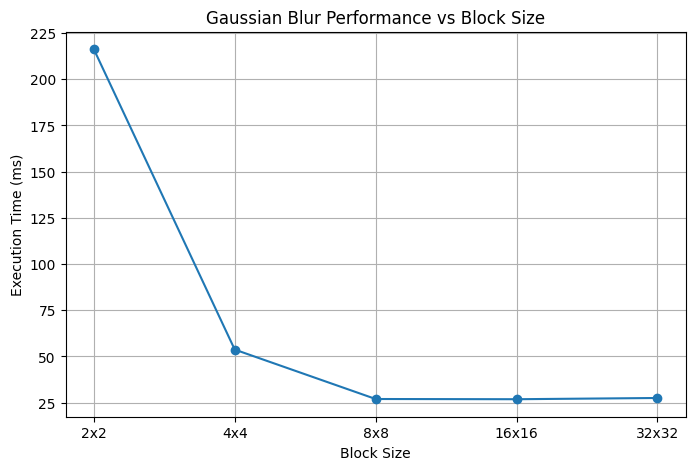

In [ ]:


labels = [f"{x}x{y}" for x, y in block_sizes]

plt.figure(figsize=(8, 5))

plt.plot(
    labels,
    times,
    marker="o"
)

plt.xlabel("Block Size")
plt.ylabel("Execution Time (ms)")
plt.title("Gaussian Blur Performance vs Block Size")
plt.grid(True)

plt.show()